# 06 — From-Scratch Control

**Identical architecture to 05** (784→128→64→64→32→10, same dropout pattern,
same hyperparameters) but trained **from scratch** with all params trainable.
No simplex backbone, no frozen layers.

This is the control for the core question: does simplex pre-training actually
help, or does the architecture alone reach the same place?

| | NB05 (simplex) | NB06 (control) |
|--|--|--|
| Backbone init | Simplex pre-trained | Random |
| Frozen layers | fc1, bn1, fc2, ln2 | None |
| Trainable params | 6,762 | 115,882 (all) |
| Dropout (layers 1–2) | 0.1 | 0.1 |
| Dropout (layers 3–4) | 0.0 | 0.0 |
| Everything else | identical | identical |

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

from scripts.viz_export import ExperimentTracker

import numpy as np
from sklearn.metrics import silhouette_score

torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"PyTorch {torch.__version__}")
device = torch.device("cpu")

/Users/morgancooper/miniconda3/envs/nnpo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.10.0


## 1. Load MNIST

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: x.view(-1)),
])

data_root = os.path.join(PROJECT_ROOT, "data")
full_train_dataset = datasets.MNIST(root=data_root, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=data_root, train=False, download=True, transform=transform)

train_dataset, val_dataset = random_split(
    full_train_dataset, [48000, 12000],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, generator=torch.Generator().manual_seed(0))
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 48000, Val: 12000, Test: 10000


## 2. Define Model (From Scratch)

Same `ExtendedSimplexNet` architecture as NB05 — same layer sizes, same dropout
pattern (0.1 on layers 1–2, 0.0 on layers 3–4). Random init, nothing frozen.

In [3]:
# --- Hyperparameters (identical to NB05) ---
LR = 0.001
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 15
CHECKPOINT_EVERY = 10
BACKBONE_DROPOUT = 0.1
HEAD_DROPOUT = 0.0

# --- LR Scheduler (ReduceLROnPlateau) ---
SCHEDULER_PATIENCE = 2
SCHEDULER_FACTOR = 0.5
SCHEDULER_MIN_LR = 1e-6


class ExtendedSimplexNet(nn.Module):
    """Same architecture as NB05, trained from scratch."""

    def __init__(self, backbone_dropout=0.1, head_dropout=0.0):
        super().__init__()
        # --- Layers 1-2 ("backbone" in NB05, here just the first two layers) ---
        self.fc1 = nn.Linear(784, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.drop1 = nn.Dropout(backbone_dropout)
        self.fc2 = nn.Linear(128, 64)
        self.ln2 = nn.LayerNorm(64)
        self.drop2 = nn.Dropout(backbone_dropout)

        # --- Layers 3-4 + classifier ---
        self.fc3 = nn.Linear(64, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.drop3 = nn.Dropout(head_dropout)
        self.fc4 = nn.Linear(64, 32)
        self.ln4 = nn.LayerNorm(32)
        self.drop4 = nn.Dropout(head_dropout)
        self.fc5 = nn.Linear(32, 10)

    def forward(self, x):
        x = self.drop1(torch.relu(self.bn1(self.fc1(x))))
        x = self.drop2(torch.relu(self.ln2(self.fc2(x))))
        x = self.drop3(torch.relu(self.bn3(self.fc3(x))))
        x = self.drop4(torch.relu(self.ln4(self.fc4(x))))
        x = self.fc5(x)
        return x


model = ExtendedSimplexNet(backbone_dropout=BACKBONE_DROPOUT, head_dropout=HEAD_DROPOUT).to(device)

# No checkpoint loading, no freezing — all params trainable
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"From-scratch control: same architecture as NB05, all params trainable")
print(f"Trainable: {trainable:,} / {total:,} params (NB05: 6,762 / {total:,})")
print(model)

From-scratch control: same architecture as NB05, all params trainable
Trainable: 115,882 / 115,882 params (NB05: 6,762 / 115,882)
ExtendedSimplexNet(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop1): Dropout(p=0.1, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (drop2): Dropout(p=0.1, inplace=False)
  (fc3): Linear(in_features=64, out_features=64, bias=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop3): Dropout(p=0.0, inplace=False)
  (fc4): Linear(in_features=64, out_features=32, bias=True)
  (ln4): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (drop4): Dropout(p=0.0, inplace=False)
  (fc5): Linear(in_features=32, out_features=10, bias=True)
)


## 3. Pick Input Samples & Viz Samples

In [4]:
# 5 input samples: one per distinct digit (first 5 unique)
seen_labels = set()
five_images, five_labels = [], []
for img, label in full_train_dataset:
    if label not in seen_labels:
        five_images.append(img)
        five_labels.append(int(label))
        seen_labels.add(label)
    if len(seen_labels) == 5:
        break
five_images = torch.stack(five_images)
print(f"Input samples: labels={five_labels}, shape={five_images.shape}")

# 500 viz samples: 50 per class
viz_images, viz_labels = [], []
class_counts = {c: 0 for c in range(10)}
for img, label in full_train_dataset:
    label = int(label)
    if class_counts[label] < 50:
        viz_images.append(img)
        viz_labels.append(label)
        class_counts[label] += 1
    if all(v >= 50 for v in class_counts.values()):
        break
viz_images = torch.stack(viz_images)
print(f"Viz samples: {len(viz_labels)} total, shape={viz_images.shape}")

Input samples: labels=[5, 0, 4, 1, 9], shape=torch.Size([5, 784])
Viz samples: 500 total, shape=torch.Size([500, 784])


## 4. Create Tracker

In [5]:
tracker = ExperimentTracker(
    run_id="from_scratch_control",
    model_name="From-Scratch Control",
    description="Same architecture as NB05 (784\u2192128\u219264\u219264\u219232\u219210), random init, all params trainable, 15 epochs",
    hyperparameters={
        "lr": LR, "batch_size": 512, "epochs": NUM_EPOCHS,
        "weight_decay": WEIGHT_DECAY, "l1_lambda": 0,
        "backbone_dropout": BACKBONE_DROPOUT, "head_dropout": HEAD_DROPOUT,
        "pretrained_backbone": False,
        "frozen_layers": [],
        "scheduler": "ReduceLROnPlateau",
        "scheduler_patience": SCHEDULER_PATIENCE,
        "scheduler_factor": SCHEDULER_FACTOR,
        "scheduler_min_lr": SCHEDULER_MIN_LR,
    },
    model=model,
)

tracker.track("input", size=784)
tracker.track("hidden_1", model.fc1, size=128)
tracker.track("hidden_2", model.fc2, size=64)
tracker.track("hidden_3", model.fc3, size=64)
tracker.track("hidden_4", model.fc4, size=32)
tracker.track("output", model.fc5, size=10)

tracker.set_input_samples(five_images, five_labels)
tracker.set_viz_samples(viz_images, viz_labels)
tracker.enable_gradient_capture()
tracker.enable_loss_landscape()

ExperimentTracker: will write to /Users/morgancooper/NeuralNetworkProjectionOperator/scripts/../experimentation/runs/from_scratch_control_v1


## 5. Train

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=SCHEDULER_PATIENCE,
                              factor=SCHEDULER_FACTOR, min_lr=SCHEDULER_MIN_LR)

def evaluate(loader):
    model.eval()
    total_loss = correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            out = model(x)
            total_loss += criterion(out, y).item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
    return total_loss / total, correct / total

# Training history for plotting
history = {
    "epoch": [], "train_loss": [], "val_loss": [],
    "val_accuracy": [], "test_accuracy": [], "lr": [],
}

step = 0
global_batch = 0

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    for batch_idx, (batch_x, batch_y) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_y)

        loss.backward()
        tracker.capture_gradients()
        optimizer.step()

        running_loss += loss.item()
        global_batch += 1

        if global_batch % CHECKPOINT_EVERY == 0:
            val_loss, val_acc = evaluate(val_loader)
            _, test_acc = evaluate(test_loader)
            tracker.compute_loss_landscape(batch_x, batch_y, criterion)
            tracker.save_checkpoint(step=step, epoch=epoch, metrics={
                "train_loss": running_loss / (batch_idx + 1),
                "val_loss": val_loss,
                "val_accuracy": val_acc,
                "test_accuracy": test_acc,
                "lr": optimizer.param_groups[0]["lr"],
            })
            step += 1
            model.train()

    # End-of-epoch metrics
    epoch_train_loss = running_loss / len(train_loader)
    val_loss, val_acc = evaluate(val_loader)
    _, test_acc = evaluate(test_loader)
    current_lr = optimizer.param_groups[0]["lr"]

    # Step scheduler on val loss
    scheduler.step(val_loss)

    # Record history
    history["epoch"].append(epoch)
    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)
    history["test_accuracy"].append(test_acc)
    history["lr"].append(current_lr)

    print(f"Epoch {epoch}: train_loss={epoch_train_loss:.4f}, val_loss={val_loss:.4f}, "
          f"val_acc={val_acc:.4f}, test_acc={test_acc:.4f}, lr={current_lr:.6f}")

print(f"\nTraining complete \u2014 {step} checkpoints saved")

  step_000.json (epoch=0, loss=1.6098, acc=0.7385, size=4.9MB)
  step_001.json (epoch=0, loss=1.2782, acc=0.8346, size=4.8MB)
  step_002.json (epoch=0, loss=1.0583, acc=0.8732, size=4.8MB)
  step_003.json (epoch=0, loss=0.8919, acc=0.8940, size=4.8MB)
  step_004.json (epoch=0, loss=0.7474, acc=0.9120, size=4.8MB)
  step_005.json (epoch=0, loss=0.6338, acc=0.9203, size=4.8MB)
  step_006.json (epoch=0, loss=0.5425, acc=0.9271, size=4.8MB)
  step_007.json (epoch=0, loss=0.4698, acc=0.9345, size=4.8MB)
  step_008.json (epoch=0, loss=0.4116, acc=0.9394, size=4.9MB)
Epoch 0: train_loss=0.9686, val_loss=0.3924, val_acc=0.9405, test_acc=0.9475, lr=0.001000
  step_009.json (epoch=1, loss=0.3701, acc=0.9405, size=4.8MB)
  step_010.json (epoch=1, loss=0.3374, acc=0.9437, size=4.8MB)
  step_011.json (epoch=1, loss=0.3035, acc=0.9472, size=4.8MB)
  step_012.json (epoch=1, loss=0.2843, acc=0.9473, size=4.8MB)
  step_013.json (epoch=1, loss=0.2616, acc=0.9494, size=4.8MB)
  step_014.json (epoch=1, lo

## 6. Training Curves

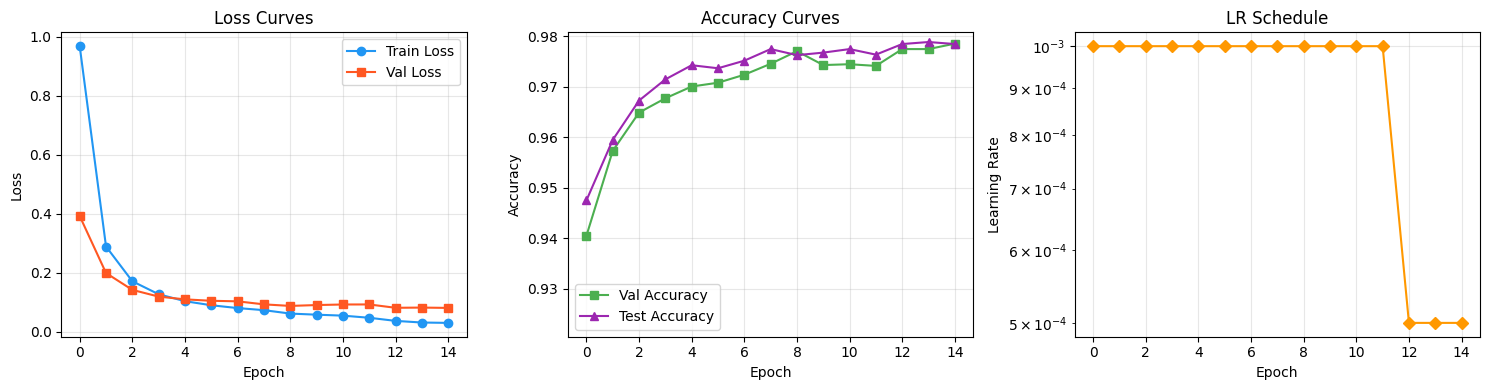

Epoch  Train Loss  Val Loss  Val Acc  Test Acc         LR
----------------------------------------------------------
    0      0.9686    0.3924   0.9405    0.9475   0.001000
    1      0.2891    0.1991   0.9573    0.9595   0.001000
    2      0.1711    0.1419   0.9649    0.9673   0.001000
    3      0.1271    0.1191   0.9677    0.9715   0.001000
    4      0.1036    0.1098   0.9701    0.9743   0.001000
    5      0.0898    0.1049   0.9708    0.9737   0.001000
    6      0.0802    0.1030   0.9724    0.9752   0.001000
    7      0.0732    0.0928   0.9746    0.9775   0.001000
    8      0.0615    0.0875   0.9771    0.9763   0.001000
    9      0.0578    0.0904   0.9743    0.9768   0.001000
   10      0.0546    0.0924   0.9745    0.9775   0.001000
   11      0.0473    0.0925   0.9742    0.9764   0.001000
   12      0.0368    0.0812   0.9775    0.9785   0.000500
   13      0.0312    0.0819   0.9775    0.9789   0.000500
   14      0.0300    0.0808   0.9786    0.9785   0.000500


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = history["epoch"]

# --- Loss ---
ax = axes[0]
ax.plot(epochs, history["train_loss"], "o-", label="Train Loss", color="#2196F3")
ax.plot(epochs, history["val_loss"], "s-", label="Val Loss", color="#FF5722")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Loss Curves")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Accuracy ---
ax = axes[1]
ax.plot(epochs, history["val_accuracy"], "s-", label="Val Accuracy", color="#4CAF50")
ax.plot(epochs, history["test_accuracy"], "^-", label="Test Accuracy", color="#9C27B0")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Curves")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=max(0, min(history["val_accuracy"]) - 0.02))

# --- Learning Rate ---
ax = axes[2]
ax.plot(epochs, history["lr"], "D-", color="#FF9800")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("LR Schedule")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print(f"{'Epoch':>5} {'Train Loss':>11} {'Val Loss':>9} {'Val Acc':>8} {'Test Acc':>9} {'LR':>10}")
print("-" * 58)
for i, ep in enumerate(epochs):
    print(f"{ep:>5d} {history['train_loss'][i]:>11.4f} {history['val_loss'][i]:>9.4f} "
          f"{history['val_accuracy'][i]:>8.4f} {history['test_accuracy'][i]:>9.4f} {history['lr'][i]:>10.6f}")

In [8]:
tracker.finalize()
print(f"Run: {tracker.run_id}")

# Final evaluation
val_loss, val_acc = evaluate(val_loader)
test_loss, test_acc = evaluate(test_loader)
print(f"\nFinal val accuracy:  {val_acc:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")
print(f"\n--- Comparison ---")
print(f"NB05 (simplex backbone, frozen, 6.8K trainable): test=0.9486")
print(f"NB06 (from scratch, all 115.9K trainable):       test={test_acc:.4f}")

# Silhouette score on test set hidden activations
hidden_acts, hidden_labels = [], []
hook_out = {}
def _hook(module, inp, out):
    hook_out['act'] = inp[0].detach()
handle = model.fc5.register_forward_hook(_hook)
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        model(x)
        hidden_acts.append(hook_out['act'].numpy())
        hidden_labels.append(y.numpy())
handle.remove()

X_hidden = np.concatenate(hidden_acts)
y_hidden = np.concatenate(hidden_labels)
n_sil = min(5000, len(X_hidden))
idx = np.random.RandomState(42).choice(len(X_hidden), n_sil, replace=False)
sil = silhouette_score(X_hidden[idx], y_hidden[idx])
print(f"\nSilhouette score (test, {X_hidden.shape[1]}D hidden): {sil:.4f}")

Finalized run 'from_scratch_control_v1' with 141 checkpoints
Run: from_scratch_control_v1

Final val accuracy:  0.9786
Final test accuracy: 0.9785

--- Comparison ---
NB05 (simplex backbone, frozen, 6.8K trainable): test=0.9486
NB06 (from scratch, all 115.9K trainable):       test=0.9785

Silhouette score (test, 32D hidden): 0.7884
